In [1]:
# This code works in Python 3.10.6
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import torch_geometric.transforms as T
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import torch
import warnings
warnings.filterwarnings('ignore')

In [2]:
import csv
import os
import os.path as osp

## PubMed dataset

In [ ]:
#Download the PubMed dataset from https://github.com/yangji9181/HNE/tree/master/Data and reference the files node.dat,label.dat,label.dat.test in order to execute the code below

In [3]:
df_nodes = pd.read_table(('PubMed/node.dat'),
                         names=['node_id', 'node_name', 'node_type', 'node_attributes'],
                         quoting=csv.QUOTE_NONE)

In [4]:
df_labels_train = pd.read_table(('PubMed/label.dat'),
                                names=['node_id', 'node_name', 'node_type', 'node_label'])

In [5]:
df_labels_test = pd.read_table(('PubMed/label.dat.test'),
                               names=['node_id', 'node_name', 'node_type', 'node_label'])

In [6]:
df_labels = pd.concat([df_labels_train, df_labels_test],ignore_index=True)

### Training data for GMM 

In [7]:
#Select the nodes of type 1 from original disease node featureswhich are labeled
df_disease=pd.merge(df_nodes, df_labels, on="node_id")[['node_id','node_attributes','node_label']]
df_disease = df_disease.reset_index()
df_disease.head()

,index,node_id,node_attributes,node_label
0,0,81,"0.293945,-1.118894,0.365789,0.826958,-1.024909...",2
1,1,382,"-0.076263,-0.1012,0.205599,-0.010939,0.011885,...",0
2,2,719,"-0.00509,-0.093002,0.155948,-1.041911,-0.11497...",1
3,3,1168,"-1.590567,-1.421712,1.546614,2.070439,-1.26965...",5
4,4,1183,"-0.047317,-0.141594,0.075213,-0.12674,-0.05318...",4


### Continuous features of 8 Disease node classes

In [8]:
def convert_string_to_float(df):
    return df['node_attributes'].apply(lambda x: np.fromstring(x, dtype=float, sep=',' ))

In [9]:
def preprocess_class(df_class):
    df_class = df_class.reset_index()
    df_class = convert_string_to_float(df_class)

    x = torch.tensor(df_class).float()
    disease_class = pd.DataFrame(x.numpy())
    return disease_class

In [10]:
class0 = df_disease[df_disease['node_label'] == 0].drop(['node_label','node_id'], axis = 1)
disease_class0 = preprocess_class(class0)
disease_class0.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.076263,-0.101200,0.205599,-0.010939,0.011885,-0.186806,0.017315,0.054221,-0.134682,0.029309,...,0.003725,-0.046961,0.022030,-0.059511,0.077090,0.027611,-0.119589,0.077600,-0.107299,0.150120
1,-0.105695,0.184201,-0.311365,-0.586918,0.041839,-0.375352,-0.209809,-0.275197,-0.187691,-0.010407,...,-0.295827,0.270551,0.139439,-0.118387,0.218033,0.240468,-0.405404,-0.024009,-0.038280,-0.079097
2,-0.027505,-0.145466,0.130640,-0.371549,0.082745,0.034039,-0.263921,0.326173,-0.230346,0.233040,...,-0.071879,-0.146309,0.144660,-0.052654,-0.092761,-0.082010,-0.002204,0.110625,-0.029077,-0.149880
3,-0.212835,0.020092,-0.067165,-0.360546,0.003719,-0.316084,-0.095670,-0.090671,-0.355869,0.123713,...,-0.042489,0.322580,0.213475,0.184327,0.126990,-0.174734,-0.356310,-0.022425,-0.208380,0.164806
4,0.176848,-0.177994,0.217688,-0.140722,-0.002420,-0.194984,-0.056105,0.126072,-0.111896,0.070906,...,-0.095619,-0.040588,0.164668,0.183074,-0.007102,-0.078018,-0.206885,-0.046569,-0.120863,0.097002


In [11]:
class1 = df_disease[df_disease['node_label'] == 1].drop(['node_label','node_id'], axis = 1)
disease_class1 = preprocess_class(class1)
disease_class1.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.005090,-0.093002,0.155948,-1.041911,-0.114979,-0.617497,0.166439,-0.113988,-0.443707,0.636185,...,-0.327394,0.439298,0.356134,0.690550,-0.308860,0.468901,0.244124,-0.058623,-0.368219,0.021397
1,0.678459,0.161107,-0.294408,-1.367651,2.103768,1.186129,1.882125,0.423219,-1.912892,1.194931,...,1.654857,1.608435,1.162236,-2.717319,-0.201214,1.197099,-1.264541,-2.922577,-1.188741,-1.307242
2,-1.681199,-0.703751,1.128087,-2.226594,-1.046119,0.636730,-0.500095,-0.239979,-0.998992,1.267447,...,2.065444,-1.046750,-2.627437,0.992201,0.717234,-2.367232,-2.050255,2.666933,-0.772199,0.401438
3,0.130749,-0.267213,1.721457,-0.982399,-0.044695,0.734526,-1.621730,0.373868,-0.232872,0.250372,...,-0.560398,0.781580,-0.162089,0.002168,0.013112,0.295674,-0.078259,0.097034,-0.650094,0.730890
4,0.465970,0.497691,-1.815122,-2.004339,-1.764053,-1.834500,0.539877,-1.023946,-1.697607,-0.490281,...,-0.737012,0.975823,-1.241157,0.261960,1.214548,-0.651538,-0.052915,-1.043717,-0.922041,1.584273


In [12]:
class2 = df_disease[df_disease['node_label'] == 2].drop(['node_label','node_id'], axis = 1)
disease_class2 = preprocess_class(class2)
disease_class2.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.293945,-1.118894,0.365789,0.826958,-1.024909,1.365870,-0.467886,0.515582,0.910748,1.669809,...,1.176890,-1.274171,-0.108948,-0.122850,0.121726,-0.147028,1.688417,-1.279368,-0.453393,-1.340375
1,-0.234695,-0.397418,-0.287049,-0.643192,-0.341378,-0.137831,0.152796,-0.083522,-0.232843,0.195185,...,0.211748,0.152090,0.104088,-0.103871,0.049093,0.222295,-0.139634,-0.290401,-0.421514,-0.226837
2,0.695679,-0.269031,-0.039114,-0.220264,0.207794,-0.019134,-0.248732,-0.059364,-0.408351,0.298378,...,0.260148,0.496637,-0.177052,-0.503436,0.183291,-0.307593,0.698607,0.043632,0.076104,0.478376
3,0.360314,-0.048848,0.084257,-0.308134,-0.118678,0.166424,-0.763351,0.002166,-0.790255,0.063675,...,-0.484946,0.004471,0.204809,-0.054277,0.325952,-0.179520,-0.097079,0.044739,-0.012146,-0.029781
4,-0.404648,-0.211988,0.180779,0.011021,0.246021,-0.108891,-0.292355,0.192935,-0.278896,0.114823,...,-0.048433,-0.053900,-0.057867,-0.046750,-0.020443,0.026236,-0.223835,-0.044477,-0.056810,-0.219431


In [13]:
class3 = df_disease[df_disease['node_label'] == 3].drop(['node_label','node_id'], axis = 1)
disease_class3 = preprocess_class(class3)
disease_class3.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.024643,0.083535,-0.118264,0.594446,-0.201284,-0.355791,-0.249425,0.963553,0.531981,0.146523,...,0.748214,0.242602,-0.510621,-1.191598,0.397599,-0.320266,0.024989,0.133490,1.125030,-0.851694
1,0.556467,-2.086023,1.777970,-0.953517,0.915395,1.392508,-1.678550,0.540311,1.287577,0.618743,...,-0.411275,0.044154,0.361089,-1.754970,0.017345,0.280704,-0.718187,-0.045025,-0.258995,-0.425449
2,0.399095,-0.033018,-0.050412,-0.308753,-0.270034,0.745800,0.109193,0.020682,0.472592,0.340427,...,0.173446,0.161498,0.315679,0.281295,-0.044803,0.013173,-0.458676,-0.137317,0.170523,0.214067
3,-0.240225,-1.536221,1.694471,0.427379,-1.573127,-1.249170,0.884610,0.263238,0.510730,1.645338,...,0.614007,0.541815,-2.998076,-2.450051,1.247795,-0.588532,3.193011,0.717154,0.347180,-1.627718
4,0.362348,-1.096200,0.676793,-0.413567,-0.772641,0.890930,-0.149459,0.236680,0.380899,0.178184,...,0.455985,-0.515523,0.660446,0.193103,0.302213,-0.151369,0.092068,0.212235,0.546388,0.454193


In [14]:
class4 = df_disease[df_disease['node_label'] == 4].drop(['node_label','node_id'], axis = 1)
disease_class4 = preprocess_class(class4)
disease_class4.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.047317,-0.141594,0.075213,-0.126740,-0.053180,-0.218182,0.010254,0.047152,-0.041381,0.002139,...,-0.163869,0.026139,0.029002,0.043187,0.089586,0.033324,-0.114441,-0.060817,-0.010271,0.124895
1,0.562200,-0.225132,1.403848,-0.900295,0.262917,0.775106,-1.395564,0.311257,-0.724682,0.510858,...,0.411451,0.706201,0.340969,0.616213,-0.581052,-0.016106,-0.312787,-0.254518,0.271065,-0.790870
2,0.132653,0.074229,0.130764,0.033300,-0.102414,-0.218270,-0.071465,0.149520,-0.059220,0.017269,...,-0.111331,0.032618,-0.101999,0.099495,0.009021,0.139706,-0.035738,0.021552,0.008510,0.002877
3,-0.017639,-0.033512,0.000192,-0.109765,0.026992,-0.011844,-0.011614,-0.025284,0.024664,0.010700,...,0.005757,0.102228,0.023747,0.007250,0.059213,0.070808,-0.047414,-0.096692,-0.043873,-0.066162
4,-0.131220,-0.051643,-0.041383,-0.281236,-0.046421,-0.136331,-0.069264,0.033541,-0.169223,0.180200,...,0.037729,-0.067685,0.098400,0.071199,0.224848,0.105085,-0.249451,-0.156987,-0.106818,0.112558


In [15]:
class5 = df_disease[df_disease['node_label'] == 5].drop(['node_label','node_id'], axis = 1)
disease_class5 = preprocess_class(class5)
disease_class5.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-1.590567,-1.421712,1.546614,2.070439,-1.269654,-3.492672,-0.985981,0.546692,-0.475412,-1.536833,...,0.422038,0.007902,-1.390627,-1.551006,0.566039,-0.957820,1.291253,-0.831003,-0.518681,-2.290930
1,1.707825,-0.382173,-1.978946,-0.982130,-0.596798,-1.058455,-0.786816,1.240825,-0.129001,0.208566,...,0.172373,3.154299,-0.672227,1.427703,1.280134,0.568588,-0.842362,-2.181951,1.627768,-0.607146
2,0.220100,-0.417449,-0.685131,0.271951,0.078659,-0.432255,0.099468,0.972583,0.090751,-0.106717,...,-0.402620,2.183498,-0.601318,1.458961,1.056984,0.751510,-1.148700,-1.398744,0.755516,-0.002951
3,-1.740684,0.606801,-1.877703,1.046687,0.026526,-0.971972,-0.062663,0.606383,-0.530064,-0.484855,...,0.776250,-1.420441,-0.033495,-0.917212,-0.367292,1.660141,-0.226066,1.478080,-0.249655,-0.803304
4,-0.115116,0.002367,-0.479038,-0.177523,0.033764,-0.129842,0.056449,-0.296631,-0.288493,-0.015120,...,-0.138466,-0.019240,-0.189517,-0.354875,0.412785,-0.289701,0.006733,0.096080,-0.055206,-0.724863


In [16]:
class6 = df_disease[df_disease['node_label'] == 6].drop(['node_label','node_id'], axis = 1)
disease_class6 = preprocess_class(class6)
disease_class6.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.705640,0.985807,1.727781,-0.572725,-1.510551,0.642899,-0.624731,-1.256330,0.380489,0.023940,...,0.237006,-0.864796,0.610489,0.725486,-0.615443,1.057366,-1.303320,-0.523200,-0.703197,0.300165
1,0.011111,-0.122398,0.108061,-0.168659,0.130440,-0.140680,-0.039575,0.006266,-0.134101,0.157674,...,-0.144526,0.049754,0.064575,0.282247,0.194395,0.082200,-0.225217,-0.088581,-0.127291,0.053279
2,1.179064,-0.248007,1.991181,0.059653,-1.148944,0.998520,-2.427823,0.023305,-1.135082,0.836730,...,0.554176,-0.339511,-0.320372,-0.973622,0.498973,0.603219,0.206073,-0.617010,0.398882,-0.659668
3,1.189486,-0.211165,1.973143,-0.170255,0.155388,0.033257,-1.330603,0.244563,-1.469571,0.941832,...,0.590651,-0.198665,0.922510,0.824605,-0.320789,-0.067372,-0.554014,-0.405515,-0.508741,-0.424119
4,0.355506,0.235083,0.229828,-0.683967,0.104608,-0.054153,-0.353290,-0.215031,-0.647038,0.664175,...,0.223206,-0.076717,0.368509,0.355019,-0.116577,0.160777,0.104109,-0.340245,-0.294386,0.067596


In [17]:
class7 = df_disease[df_disease['node_label'] == 7].drop(['node_label','node_id'], axis = 1)
disease_class7 = preprocess_class(class7)
disease_class7.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.008934,-0.107426,-0.025639,-0.182206,-0.061130,-0.204593,0.052291,0.000600,-0.019277,-0.035205,...,-0.004144,-0.114080,-0.111657,-0.027183,0.011316,0.052875,-0.172027,0.045929,-0.126126,0.006938
1,0.137979,-0.170588,0.379676,-0.133586,0.079844,-0.251604,-0.024294,-0.344566,0.012777,-0.011450,...,-0.218091,-0.112789,0.223476,0.009716,0.009727,-0.239896,-0.423860,0.127019,-0.208154,0.340889
2,-0.103373,-0.060679,0.032110,-0.060401,-0.028959,-0.040241,0.008029,0.002173,0.159710,0.096757,...,-0.051615,0.114342,-0.094867,0.182887,0.080529,0.035603,-0.051109,-0.036864,0.006196,-0.052524
3,-0.599056,-1.798572,0.036479,0.219410,-0.855767,-0.576619,1.906403,-1.219357,2.067185,-0.082776,...,0.970780,1.856780,-0.228110,0.857764,0.265307,0.256848,-0.150381,-0.285863,-1.042520,0.592658
4,1.363495,-0.065928,1.405803,-0.537324,-0.262326,-1.180556,0.268985,-0.565657,-0.405827,-1.344875,...,-0.853315,-0.385528,1.336321,0.695131,-0.434372,1.154994,0.586074,0.639965,-1.056659,-0.311664


### Fit Gaussian Mixture Models to 8 Disease node classes

In [18]:
new_features_dict = {}

In [19]:
def sample_features(model,node_type, n_samples):

    smpls = model.sample(n_samples)
    print("no of class {} node samples - {}".format(node_type, n_samples))
    return smpls[0]

In [20]:
def fit_sample_gm(df_class, node_type, n_samples):
    #fit
    model = GaussianMixture(n_components=1, covariance_type='full', random_state = 0)
    model.fit(df_class)

    #sample
    smpls = sample_features(model, node_type, n_samples)
    new_features_dict[node_type] = smpls

In [21]:
fit_sample_gm(disease_class0, 'disease0', disease_class0.shape[0])
fit_sample_gm(disease_class1, 'disease1', disease_class1.shape[0])
fit_sample_gm(disease_class2, 'disease2', disease_class2.shape[0])
fit_sample_gm(disease_class3, 'disease3', disease_class3.shape[0])
fit_sample_gm(disease_class4, 'disease4', disease_class4.shape[0])
fit_sample_gm(disease_class5, 'disease5', disease_class5.shape[0])
fit_sample_gm(disease_class6, 'disease6', disease_class6.shape[0])
fit_sample_gm(disease_class7, 'disease7', disease_class7.shape[0])

no of class disease0 node samples - 69
no of class disease1 node samples - 52
no of class disease2 node samples - 48
no of class disease3 node samples - 39
no of class disease4 node samples - 98
no of class disease5 node samples - 64
no of class disease6 node samples - 42
no of class disease7 node samples - 42


### Continuous features sampled using Gaussian Mixure Models

In [22]:
disease0_sampled = pd.DataFrame(new_features_dict['disease0'])
disease0_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.073579,-0.391046,0.184022,-2.041992,-1.082370,0.228458,-0.862203,0.415514,-0.649960,1.164591,...,1.912383,0.497476,-0.129710,-0.043883,0.343216,-0.887523,0.550757,-0.648092,-1.265959,0.283294
1,0.106466,0.143970,0.010853,-0.595627,-0.138316,-0.228551,0.019814,0.530859,0.041056,0.520343,...,0.353610,-0.667367,-0.594733,0.513279,0.139036,-0.381148,0.498907,-0.338879,-0.185585,0.173174
2,0.059134,0.388153,-1.143994,-0.331898,-0.192207,0.032784,0.131577,-0.235477,0.203089,-0.128999,...,-0.159387,-0.021872,1.091088,-0.187746,-0.275662,0.726483,-0.613477,0.174437,0.102610,0.967016
3,0.422650,0.114632,0.000787,-0.164871,0.015462,-0.275953,-0.137363,0.468837,-1.175956,-0.056712,...,-0.863857,-0.942312,0.345843,0.057504,-0.321908,-0.796291,-0.673305,0.260500,0.116807,0.054539
4,-0.249131,-0.625418,-0.059482,-1.582514,-0.302834,0.410816,0.324075,-0.270145,-0.077562,0.531919,...,0.909437,1.016302,0.003689,-0.116997,0.197486,-0.476676,-0.233591,-0.307209,-0.585189,-0.075181


In [23]:
disease1_sampled = pd.DataFrame(new_features_dict['disease1'])
disease1_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.642176,-0.988077,0.795610,-2.050227,-0.146192,-1.576586,-0.423898,0.513851,-0.990989,0.050063,...,-0.065807,-1.484293,-0.006599,1.641343,0.284017,-1.225226,0.485950,0.826980,-0.308803,-0.588605
1,-1.107746,0.073932,-0.021660,-1.849840,-0.953864,-0.190054,-0.686810,-0.144664,-1.166847,0.275383,...,1.126490,0.294575,-1.010986,-0.083750,-0.294420,0.029985,0.696374,0.595870,-0.953225,-0.798322
2,0.008894,-0.416082,0.272990,-0.850750,-1.009699,0.266478,-0.512914,-0.034204,-0.385599,1.473446,...,-0.095835,0.391280,-1.611172,-0.544739,-0.589144,-1.105230,0.961950,1.096423,-0.471201,0.156003
3,0.271474,0.077408,-1.040943,-0.542802,-1.202184,-0.483726,1.001061,-0.471611,-0.548432,0.418822,...,0.092963,1.471688,-1.097919,-0.419153,-0.689393,0.234848,0.446915,-1.875565,-0.856107,-0.940069
4,0.905778,-0.435941,-0.002494,0.697462,-0.463073,-0.372949,-0.239608,0.486500,-0.321150,0.369063,...,-0.098443,-0.152641,1.596539,0.362921,0.027569,-0.174623,-0.036272,0.445774,-0.179997,0.011645


In [24]:
disease2_sampled = pd.DataFrame(new_features_dict['disease2'])
disease2_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.371998,0.479735,0.901110,0.596737,-1.255456,-0.809848,-0.189974,-1.140437,-0.053406,0.026722,...,-0.624463,0.176681,1.046621,0.203602,0.611581,0.768002,-0.352236,-1.163609,-0.449440,-0.290210
1,0.784712,-0.777513,0.284186,-0.654555,-0.880484,-0.339405,-1.142032,0.054676,0.067222,0.794776,...,0.240497,0.298006,-0.581315,0.262656,-0.001068,0.707484,1.257551,-0.413483,-0.219920,-0.060830
2,1.387744,-0.086786,-0.957671,-0.262998,0.142293,-0.014787,-0.743750,0.071682,-0.031196,0.125275,...,-0.519115,0.203075,-1.092571,-0.575779,0.670586,-0.825986,0.759974,-0.075352,-0.155605,0.143352
3,-0.368083,-0.997970,-1.225294,-0.713065,0.311957,0.390250,-1.157165,0.376268,0.341564,0.666694,...,-0.754612,-0.048891,-0.734615,0.326603,0.576073,0.106081,0.050031,-0.181811,-0.378639,0.141039
4,-0.203995,0.281863,0.378428,0.175518,0.292424,-0.047159,0.828444,-0.126973,-1.043436,0.469463,...,-0.447211,-0.475131,1.041501,1.105096,0.503671,0.452449,-0.555173,-0.251820,0.541943,-0.033496


In [25]:
disease3_sampled = pd.DataFrame(new_features_dict['disease3'])
disease3_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.465598,-1.113296,0.605946,-0.071522,-0.441458,0.149635,1.835540,0.727576,0.954851,1.384264,...,-0.205343,1.869879,-0.001234,-0.006669,0.456440,-0.010567,0.273747,-0.373697,-0.090011,0.038796
1,-0.189990,0.182935,-0.513049,-0.056248,0.092866,-0.120902,0.312845,0.444654,0.476977,0.013665,...,-0.450871,0.436369,1.392767,0.302004,0.187710,0.330920,-0.980448,-0.402587,0.073143,0.169676
2,-0.279398,0.229106,-0.540577,-0.108864,-0.639934,0.046168,0.429075,1.028804,-0.194087,-0.084895,...,0.093000,0.121975,-0.010164,0.358352,-0.374322,0.599461,-0.328935,-1.427205,0.218677,-0.535842
3,-0.388280,0.594925,-0.926483,0.232252,-0.198565,-0.662724,-0.718665,-0.570208,-0.890994,0.089434,...,0.045237,-0.447031,0.713789,0.721165,0.471274,0.286962,-0.119668,-0.627834,-0.083989,-0.130443
4,-0.150679,-0.536800,0.750704,-0.443575,-0.299977,-0.494174,-0.415850,0.518918,0.538300,0.605704,...,-0.233702,0.211944,-1.045749,-1.064279,0.490634,0.281510,0.301874,-0.073968,-0.067017,-1.155975


In [26]:
disease4_sampled = pd.DataFrame(new_features_dict['disease4'])
disease4_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.490720,0.458776,-0.148004,0.036622,0.286336,0.012811,-0.770664,-0.505707,0.454448,0.271319,...,-0.012963,0.199929,-0.700255,-0.314111,0.415894,-0.713988,-0.501649,0.590314,0.593915,-0.633583
1,-0.260735,0.023372,1.191564,-0.674492,0.338238,0.136784,-1.228394,0.181074,-0.908486,0.430919,...,-0.077065,-0.012256,-0.235472,0.591174,-0.614257,0.048366,-0.527774,0.144726,-0.025670,0.054558
2,0.571765,-0.148736,0.613518,-0.184991,0.229507,0.173463,-0.341382,0.312702,-0.495424,-0.177900,...,0.115338,0.536605,0.863161,0.518479,0.078168,0.844265,-0.263580,-0.144769,0.121879,0.915105
3,0.439377,-1.431019,1.740479,-0.793958,-0.897648,1.058775,-0.985524,0.703159,-0.810516,1.534728,...,0.052722,-0.154345,0.240997,0.310902,-0.331952,-0.110429,-0.546128,-0.120282,-0.149227,0.420836
4,0.125579,0.196977,0.348433,0.504337,-0.551541,-0.290281,0.114014,0.014518,0.316246,-0.484591,...,-0.222540,0.193933,-0.206747,-0.763532,0.452542,0.351996,-0.261044,-0.171822,0.339970,-0.671913


In [27]:
disease5_sampled = pd.DataFrame(new_features_dict['disease5'])
disease5_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.857019,0.402814,-1.699331,-1.452056,0.672566,-0.668078,-0.842683,1.073444,1.006769,0.996653,...,0.348450,1.532823,0.769753,0.534520,1.150958,1.122991,-0.564776,-2.811273,2.527015,-1.330165
1,0.754395,-0.658489,0.029166,-1.636382,0.252442,0.139714,0.124985,0.656577,-0.058941,0.447048,...,0.221673,1.456702,-0.923041,0.436258,0.003632,1.248672,0.045227,-1.085779,-0.217027,-0.442531
2,-0.171988,0.655970,-0.576770,-0.688819,-0.315232,1.096245,-0.673161,0.300343,-0.042281,-0.684427,...,0.049278,0.192146,0.224330,-0.243050,0.495468,0.606320,0.181894,-0.157694,-0.988762,-1.147347
3,-0.527632,-0.136908,2.827330,0.023675,-1.022635,0.685209,-0.086463,-0.825061,-1.142760,-0.341685,...,-0.310130,-0.783292,0.829334,0.251792,-1.091464,0.046774,1.045149,0.178650,-1.458223,-0.291897
4,-0.361980,0.030848,-0.422475,0.684672,-0.255543,-0.876122,0.487142,-0.739058,0.511782,0.025187,...,0.116612,1.734938,0.526440,-0.471640,0.669066,-1.105071,-0.601601,0.129873,0.991351,-0.891527


In [28]:
disease6_sampled = pd.DataFrame(new_features_dict['disease6'])
disease6_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.116619,0.192200,-0.750954,1.292933,-0.122637,-0.060804,-0.157913,-0.285800,0.200252,0.440975,...,-0.778221,-0.593861,0.438135,-0.959018,-0.261515,-0.175208,0.150522,0.341439,0.444717,-0.192696
1,0.826876,-0.533580,0.752162,0.463961,-0.319207,-0.312050,-1.008679,-0.313712,-0.382910,0.992863,...,0.081748,-0.608864,0.082148,0.336134,-0.199790,-0.303814,-0.188535,-0.360755,0.022417,-0.481666
2,0.887774,-0.106689,1.341995,-0.542956,-0.854629,0.256717,-0.826466,-0.198682,-0.572842,-0.208956,...,0.783256,-0.479746,0.146781,0.092935,1.169963,0.334528,-0.588994,-0.513122,-0.219909,-0.985616
3,0.018318,-0.123142,1.410886,-0.091494,-0.380380,0.075753,-1.051125,-0.267460,0.436629,-0.329259,...,0.610199,-0.371232,-0.198884,0.634014,-0.161907,0.382878,-1.045325,-0.481905,-0.847452,0.460065
4,-0.627877,0.356528,-0.752009,-0.333216,0.521629,-0.221873,0.265372,0.014664,-0.748975,-0.480246,...,-0.496029,-0.519577,0.312962,0.135587,-0.568676,0.127900,0.361352,0.093222,-0.504240,0.676375


In [29]:
disease7_sampled = pd.DataFrame(new_features_dict['disease7'])
disease7_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.411229,0.443188,-1.419262,0.345421,-1.786057,-0.342878,-1.070405,0.992075,-1.101026,0.489989,...,0.481195,-0.575216,-0.263810,-0.313721,-0.463901,-0.067596,0.382688,-0.600579,-0.400686,-0.261719
1,1.268681,-0.210153,-0.124913,-0.068533,-0.978325,-1.115594,0.782536,-0.243184,0.203965,0.581419,...,0.604241,0.254197,0.074475,-0.017333,-0.324671,-0.333231,0.540041,-0.544852,-1.299204,0.713191
2,0.940050,0.235288,1.707688,-0.609766,-0.462490,-1.346383,0.599340,-0.341578,-0.374149,-0.556738,...,-1.018514,0.072504,-0.196928,1.377518,0.108670,-0.221019,0.254416,-0.571211,-0.429454,-0.328705
3,0.202817,-0.579815,1.228147,-0.060211,-0.854576,-0.624308,1.040445,-2.161955,1.318275,0.340401,...,0.108622,1.738406,-0.229342,0.942256,0.247860,0.523941,0.307243,0.184783,-0.672971,-0.196094
4,-0.526617,0.765041,-0.096194,-0.543933,0.076179,0.656959,-0.530783,0.089045,-0.346938,0.498370,...,0.057672,0.052034,-0.283963,-0.134927,-0.068009,0.073376,-0.312888,0.002365,0.444820,-0.083418


### Pairwise cosine similarity of all features for real and synthetic distributions

In [30]:
def cosine_sim(original,sampled):
    return cosine_similarity(np.array(original), np.array(sampled))

Disease class 0

In [31]:
cosine_sim(disease_class0, disease0_sampled)

array([[ 0.05481178,  0.03851231,  0.07405206, ...,  0.39154505,
         0.01706168,  0.03877022],
       [ 0.22545232,  0.00135011,  0.35198543, ...,  0.32262412,
        -0.30553823,  0.18000029],
       [ 0.33573085,  0.13808544,  0.02763555, ...,  0.69713343,
        -0.30940134,  0.18084554],
       ...,
       [ 0.4120793 ,  0.21515415,  0.26390037, ...,  0.53569972,
        -0.34019069,  0.31877044],
       [ 0.3397037 ,  0.09768055,  0.09385218, ...,  0.51836704,
        -0.10241224,  0.29670582],
       [ 0.25441473,  0.10322518,  0.45085004, ...,  0.22660496,
        -0.30754238,  0.16728141]])

In [32]:
sns.set(font_scale=1.4)

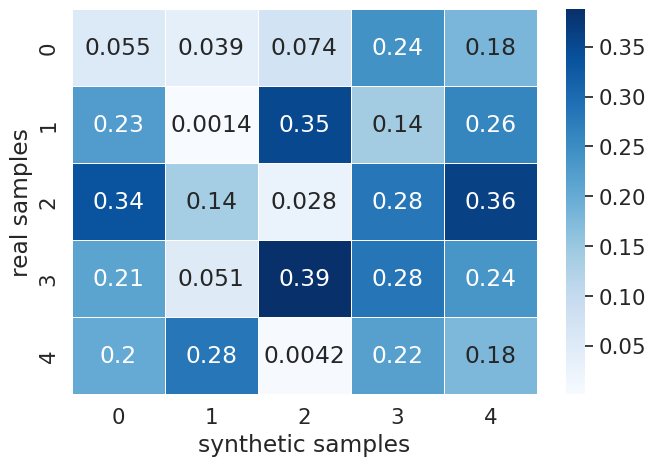

In [33]:
fig, ax = plt.subplots(figsize=(7.5,5)) 
sns.heatmap(cosine_sim(disease_class0.iloc[:5],disease0_sampled.iloc[:5]), 
            xticklabels = 1, annot=True, yticklabels = 1,fmt=".2g",
            cmap='Blues', linewidth=.5, ax=ax)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [34]:
 #Average cosine similarity for class 0
avg_cossim_class0 = np.mean(cosine_sim(disease_class0,disease0_sampled))
avg_cossim_class0

0.14236568038093486

Disease class 1

In [35]:
cosine_sim(disease_class1, disease1_sampled)

array([[ 0.41961521,  0.21903311, -0.00800716, ..., -0.27531475,
         0.21710329, -0.02270362],
       [-0.32573193,  0.0979093 ,  0.21701267, ...,  0.05143032,
        -0.01278647, -0.39804337],
       [ 0.11706896,  0.50989412,  0.46737957, ...,  0.189138  ,
         0.49529795,  0.05543123],
       ...,
       [-0.24883395,  0.36879743,  0.14976417, ...,  0.05834761,
         0.27465473, -0.43285276],
       [ 0.00347381,  0.1004883 ,  0.05677062, ...,  0.04712858,
         0.19784737, -0.04093954],
       [-0.13813474,  0.14225483, -0.00255725, ...,  0.31700927,
         0.19346131, -0.31305171]])

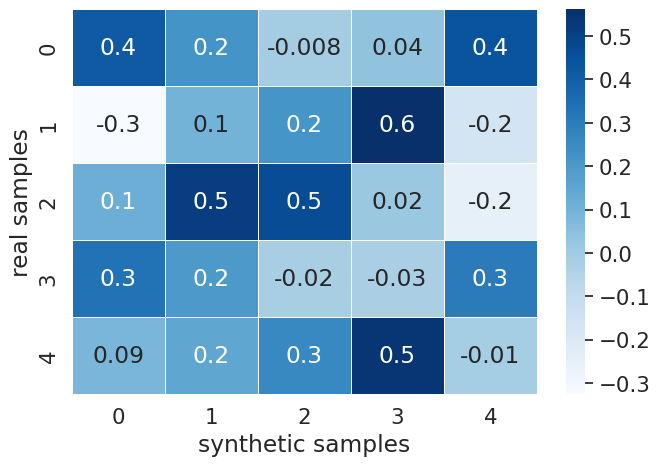

In [36]:
fig, ax = plt.subplots(figsize=(7.5,5))  
sns.heatmap(cosine_sim(disease_class1.iloc[:5],disease1_sampled.iloc[:5]), 
            xticklabels = 1, annot=True, yticklabels = 1,fmt=".1g", cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [37]:
 #Average cosine similarity for class 1
avg_cossim_class1 = np.mean(cosine_sim(disease_class1,disease1_sampled))
avg_cossim_class1

0.08363267866281825

Disease class 2

In [38]:
cosine_sim(disease_class2, disease2_sampled)

array([[-0.12207439,  0.2619189 , -0.17573158, ...,  0.23396386,
         0.08587103, -0.02244733],
       [ 0.23092441,  0.18897329,  0.03330494, ...,  0.22797078,
         0.26179151,  0.13629133],
       [ 0.0510406 ,  0.38717007,  0.55807826, ..., -0.12860517,
         0.23579242,  0.29694235],
       ...,
       [ 0.30981204,  0.39573465,  0.1902333 , ...,  0.12099258,
         0.28705762,  0.15220961],
       [ 0.0756211 ,  0.16222622,  0.19652502, ...,  0.04119402,
         0.00208946, -0.11270949],
       [-0.58820156,  0.24601661,  0.53720035, ..., -0.1146188 ,
        -0.45747257, -0.05136707]])

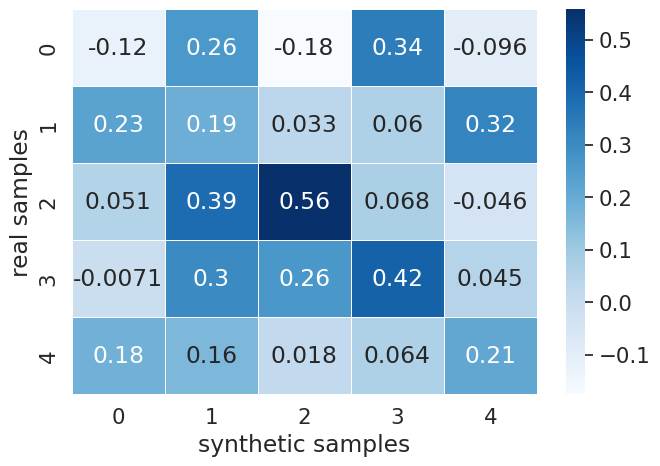

In [39]:
fig, ax = plt.subplots(figsize=(7.5,5)) 
sns.heatmap(cosine_sim(disease_class2.iloc[:5],disease2_sampled.iloc[:5]), 
            xticklabels = 1, annot=True, yticklabels = 1,fmt=".2g", cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [40]:
 #Average cosine similarity for class 2
avg_cossim_class2 = np.mean(cosine_sim(disease_class2,disease2_sampled))
avg_cossim_class2

0.11890516382666988

Disease class 3

In [41]:
cosine_sim(disease_class3, disease3_sampled)

array([[ 0.29141738,  0.34492132,  0.15200186, ...,  0.1641956 ,
         0.2603908 , -0.01641456],
       [ 0.51008273,  0.3472409 , -0.21570856, ...,  0.52363881,
         0.19278433,  0.15405713],
       [ 0.38327199,  0.34709136,  0.03346398, ...,  0.13761777,
         0.02329629,  0.12960131],
       ...,
       [ 0.1700604 ,  0.27364455,  0.04910578, ...,  0.14774022,
        -0.13868189,  0.11091554],
       [-0.06372553,  0.31883925,  0.07127758, ...,  0.18360984,
         0.06272009, -0.34996164],
       [-0.00158655, -0.13619524,  0.15400421, ..., -0.03024371,
         0.00770763, -0.08918228]])

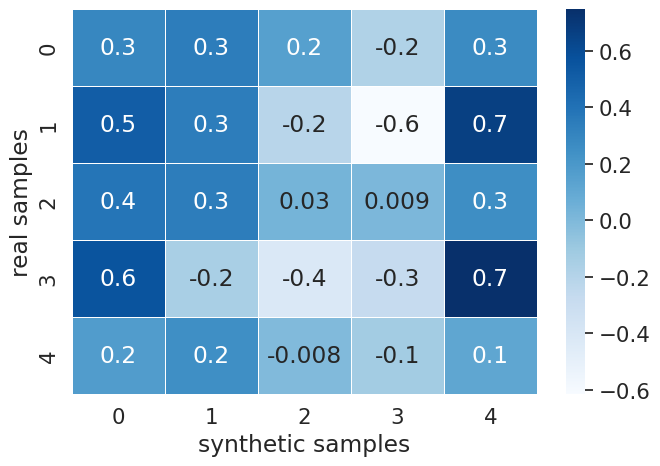

In [42]:
fig, ax = plt.subplots(figsize=(7.5,5)) 
sns.heatmap(cosine_sim(disease_class3.iloc[:5],disease3_sampled.iloc[:5]), 
            xticklabels = 1, annot=True, yticklabels = 1,fmt=".1g", cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [43]:
 #Average cosine similarity for class 3
avg_cossim_class3 = np.mean(cosine_sim(disease_class3,disease3_sampled))
avg_cossim_class3

0.09142915990194624

Disease class 4

In [44]:
cosine_sim(disease_class4, disease4_sampled)

array([[-0.0435354 ,  0.21349511,  0.32144083, ...,  0.13810983,
         0.33352923,  0.13307298],
       [ 0.15426147,  0.46552911,  0.45510863, ..., -0.10326804,
         0.35780456,  0.23517221],
       [-0.12688545,  0.12062115,  0.31662454, ...,  0.07980014,
         0.21651465, -0.00450542],
       ...,
       [-0.08602761,  0.29805168,  0.4313451 , ...,  0.07422718,
         0.51297306,  0.0642377 ],
       [-0.22574906,  0.24323118,  0.39621532, ...,  0.01547143,
         0.45145894,  0.0735425 ],
       [-0.09893571,  0.16896391,  0.39890344, ...,  0.03802193,
         0.39025247,  0.11306197]])

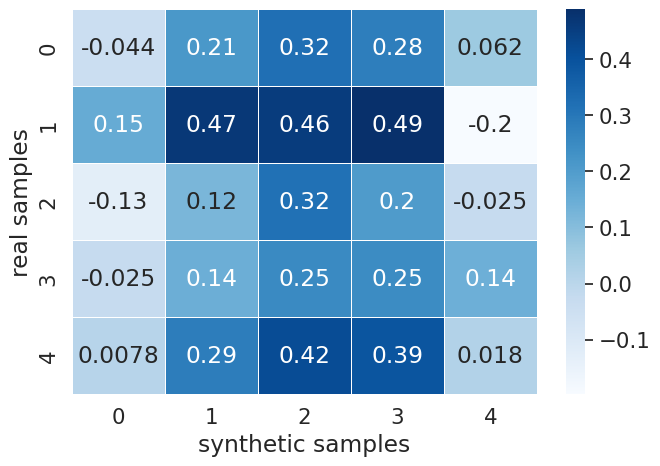

In [45]:
fig, ax = plt.subplots(figsize=(7.5,5)) 
sns.heatmap(cosine_sim(disease_class4.iloc[:5],disease4_sampled.iloc[:5]), 
            xticklabels = 1, annot=True, yticklabels = 1,fmt=".2g", cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [46]:
 #Average cosine similarity for class 4
avg_cossim_class4 = np.mean(cosine_sim(disease_class4,disease4_sampled))
avg_cossim_class4

0.18294615702763178

Disease class 5

In [47]:
cosine_sim(disease_class5, disease5_sampled)

array([[-0.1566156 ,  0.09627383,  0.08716249, ...,  0.05767461,
         0.25405989,  0.13187422],
       [ 0.51378479,  0.35040033, -0.10345811, ...,  0.22569341,
        -0.20262256,  0.21230702],
       [ 0.41322234,  0.35115646, -0.03838005, ...,  0.2290942 ,
        -0.1832749 ,  0.22285974],
       ...,
       [ 0.15145549,  0.07390915, -0.07882208, ...,  0.21712484,
        -0.0060878 ,  0.06525166],
       [-0.07055095, -0.1720439 , -0.01002208, ..., -0.05089699,
        -0.0122622 , -0.00089004],
       [-0.12748157,  0.00607758,  0.09267331, ...,  0.05130604,
         0.13118385,  0.11385091]])

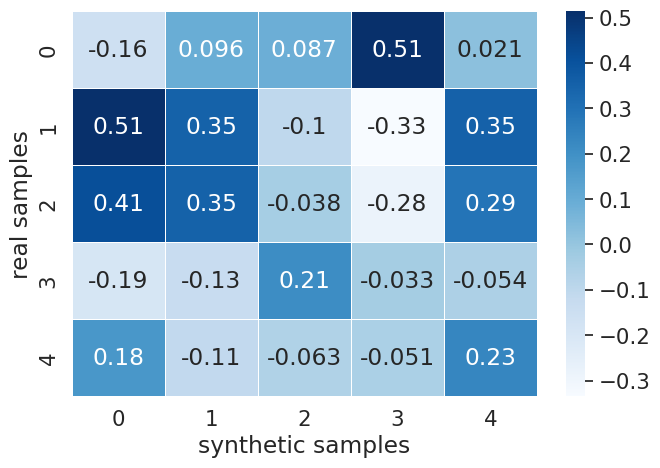

In [48]:
fig, ax = plt.subplots(figsize=(7.5,5)) 
sns.heatmap(cosine_sim(disease_class5.iloc[:5],disease5_sampled.iloc[:5]), 
            xticklabels = 1, annot=True, yticklabels = 1,fmt=".2g", cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [49]:
 #Average cosine similarity for class 5
avg_cossim_class5 = np.mean(cosine_sim(disease_class5,disease5_sampled))
avg_cossim_class5

0.06624213958064595

Disease class 6

In [50]:
cosine_sim(disease_class6, disease6_sampled)

array([[ 0.11832898,  0.58540792,  0.51025122, ...,  0.36284413,
         0.18840556,  0.39544412],
       [ 0.0322019 ,  0.36466524,  0.32542322, ...,  0.59274236,
        -0.0729384 ,  0.44505861],
       [ 0.00439078,  0.72874665,  0.64711851, ..., -0.0138451 ,
        -0.04421339,  0.37892537],
       ...,
       [ 0.16026497,  0.17970538,  0.12798666, ...,  0.2352088 ,
         0.07688931,  0.17293945],
       [ 0.09359764,  0.5585173 ,  0.41926288, ...,  0.36468569,
         0.10327885,  0.55466958],
       [-0.09171899,  0.67980336,  0.68866075, ...,  0.34067776,
         0.06758442,  0.37671074]])

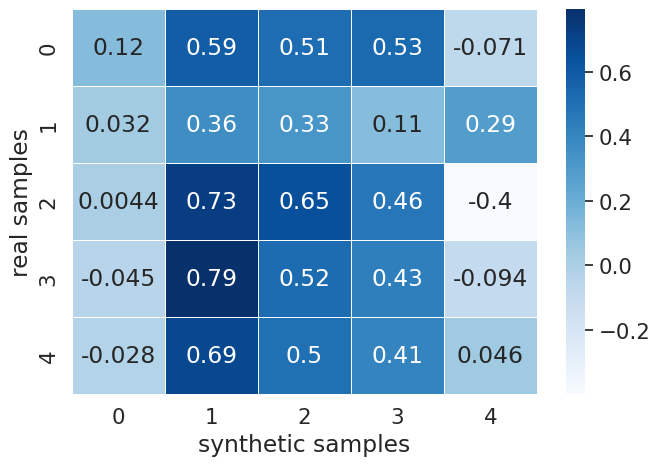

In [51]:
fig, ax = plt.subplots(figsize=(7.5,5)) 
sns.heatmap(cosine_sim(disease_class6.iloc[:5],disease6_sampled.iloc[:5]), 
            xticklabels = 1, annot=True, yticklabels = 1,fmt=".2g", cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [52]:
 #Average cosine similarity for class 6
avg_cossim_class6 = np.mean(cosine_sim(disease_class6,disease6_sampled))
avg_cossim_class6

0.19316557092350847

Disease class 7

In [53]:
cosine_sim(disease_class7, disease7_sampled)

array([[-0.00169538,  0.09974472,  0.23788884, ...,  0.02082804,
         0.21260704,  0.18322679],
       [-0.31428176,  0.4135713 ,  0.64220122, ...,  0.16332871,
         0.36973892,  0.29822031],
       [ 0.06063598, -0.01010252,  0.1361647 , ...,  0.02268526,
         0.13652324,  0.13949172],
       ...,
       [-0.32548287,  0.59753022,  0.59842994, ...,  0.24366812,
         0.33322283,  0.41108791],
       [-0.10650765,  0.35642171,  0.48038349, ...,  0.27596608,
         0.36090365,  0.34990849],
       [-0.24094716,  0.75539587,  0.71843242, ..., -0.05083534,
         0.18437387,  0.28683135]])

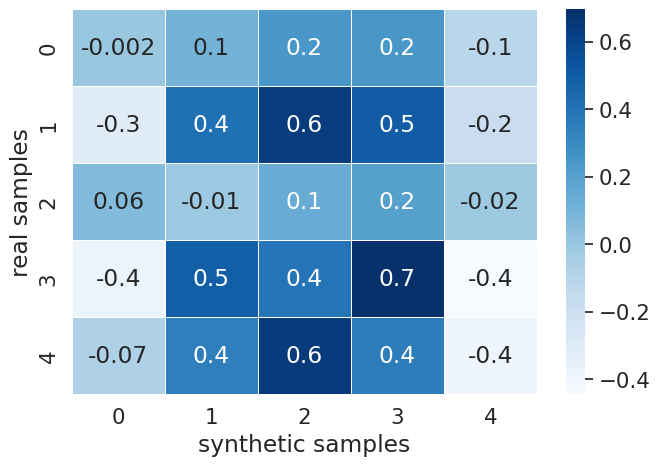

In [54]:
fig, ax = plt.subplots(figsize=(7.5,5)) 
sns.heatmap(cosine_sim(disease_class7.iloc[:5],disease7_sampled.iloc[:5]), 
            xticklabels = 1, annot=True, yticklabels = 1,fmt=".1g", cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [55]:
#Average cosine similarity for class 7
avg_cossim_class7 = np.mean(cosine_sim(disease_class7,disease7_sampled))
avg_cossim_class7

0.20787475518840884

 Average cosine similarity for all classes

In [56]:
(avg_cossim_class0 + avg_cossim_class1 +avg_cossim_class2 + avg_cossim_class3 + avg_cossim_class4 + 
 avg_cossim_class5 +avg_cossim_class6 + avg_cossim_class7)/8

0.13582016318657053